# INBreast EDA

This notebook describes my exploratory dataset analysis of the INBreast dataset (Moreira et al. (2012))

Firstly, we import some libraries used throughout the notebook.

## Imports

In [1]:
from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import pydicom

## Metadata File Review

The INbreast dataset provides a single CSV file with metadata for all cases:

- `datasets/INbreast Release 1.0/INbreast.csv`

The dataset includes:
- 410 mammography images from 115 cases
- Images in DICOM format
- ROI masks and XML annotations for findings
- Medical reports

In [2]:
INBREAST_ROOT = Path("../datasets/INbreast Release 1.0")

## ROI File Parsing

The ROI files are in Apple/NeXT typedstream binary format. We need to extract
the coordinate points that define the region of interest boundaries.

In [3]:
def parse_roi_file(roi_path):
    """
    Parse an INbreast ROI file and extract coordinate points.

    The ROI files are in Apple/NeXT typedstream binary format containing
    NSKeyedArchiver serialized objects with coordinate points.

    Args:
        roi_path: Path to the .roi file

    Returns:
        dict with:
            - 'points': List of (x, y) tuples representing the ROI boundary
            - 'roi_type': Type of ROI (e.g., 'Mass')
            - 'raw_data': Raw bytes for debugging
    """
    if not roi_path.exists():
        return None

    # Read the binary file
    file_bytes = roi_path.read_bytes()

    # Convert bytes to string (ignoring errors for binary data)
    file_str = file_bytes.decode('latin-1')

    # Extract coordinate points using regex
    # Points are in format {x, y}
    coord_pattern = r'\{([\d.-]+),\s*([\d.-]+)\}'
    matches = re.findall(coord_pattern, file_str)

    # Convert string coordinates to float tuples
    points = [(float(x), float(y)) for x, y in matches if not (float(x) == 0 and float(y) == 0)]

    # Try to extract ROI type (e.g., "Mass", "Calcification")
    roi_type = None
    type_patterns = ['Mass', 'Calcification', 'Cluster', 'Distortion']
    for pattern in type_patterns:
        if pattern in file_str:
            roi_type = pattern
            break

    return {
        'points': points,
        'roi_type': roi_type,
        'num_points': len(points),
        'raw_bytes': file_bytes
    }

In [4]:
def load_roi_for_image(file_name, roi_dir):
    """
    Load ROI data for a specific image file.

    Args:
        file_name: Image file name (without extension)
        roi_dir: Path to the AllROI directory

    Returns:
        Parsed ROI data or None if not found
    """
    roi_file = roi_dir / f"{file_name}.roi"
    if roi_file.exists():
        return parse_roi_file(roi_file)
    return None

In [5]:
def get_all_rois(inbreast_df, roi_dir):
    """
    Load all ROI files for images in the dataframe.

    Args:
        inbreast_df: DataFrame with INbreast metadata
        roi_dir: Path to the AllROI directory

    Returns:
        Dictionary mapping file names to ROI data
    """
    rois = {}
    for _, row in inbreast_df.iterrows():
        file_name = str(row['File Name'])
        roi_data = load_roi_for_image(file_name, roi_dir)
        if roi_data:
            rois[file_name] = roi_data
    return rois

In [6]:
inbreast_df = pd.read_csv(INBREAST_ROOT / "INbreast.csv", sep=";")
inbreast_df.head()

,Patient ID,Patient age,Laterality,View,Acquisition date,File Name,ACR,Bi-Rads
0,removed,removed,R,CC,201001,22678622,4,1
1,removed,removed,L,CC,201001,22678646,4,3
2,removed,removed,R,MLO,201001,22678670,4,1
3,removed,removed,L,MLO,201001,22678694,4,3
4,removed,removed,R,CC,201001,22614074,2,5


In [7]:
print(f"Total number of images: {len(inbreast_df)}")
print(f"Number of unique patients: {inbreast_df['Patient ID'].nunique()}")
print(f"\nDataset shape: {inbreast_df.shape}")

Total number of images: 410
Number of unique patients: 1

Dataset shape: (410, 8)


In [8]:
# Check the columns
print("Columns:")
for col in inbreast_df.columns:
    print(f"  - {col}")

Columns:
  - Patient ID
  - Patient age
  - Laterality
  - View
  - Acquisition date
  - File Name
  - ACR
  - Bi-Rads


## Image Extraction and Visualization

Let's look at how to load and display DICOM images from the INbreast dataset.

We know from the paper, that

Mammography comprehends the recording of two views for each breast:
- the craniocaudal (CC) view, which is a top to bottom view
- mediolateral oblique (MLO) view, which is a side view

I'll take a look at one example of each.

In [22]:
inbreast_df

,Patient ID,Patient age,Laterality,View,Acquisition date,File Name,ACR,Bi-Rads
0,removed,removed,R,CC,201001,22678622,4,1
1,removed,removed,L,CC,201001,22678646,4,3
2,removed,removed,R,MLO,201001,22678670,4,1
3,removed,removed,L,MLO,201001,22678694,4,3
4,removed,removed,R,CC,201001,22614074,2,5
...,...,...,...,...,...,...,...,...
405,removed,removed,L,MLO,201001,22613848,2,1
406,removed,removed,L,MLO,200802,24055725,4,2
407,removed,removed,R,MLO,200802,24055752,4,2
408,removed,removed,L,CC,200802,24055779,4,2


In [25]:
# Get a sample image
sample_row = inbreast_df[(inbreast_df.View == "MLO") & (inbreast_df["Bi-Rads"] == "5")].iloc[0]
sample_filename = sample_row['File Name']
print(f"Sample image filename: {sample_filename}")

Sample image filename: 22614127


In [26]:
sample_row

Patient ID           removed
Patient age          removed
Laterality                 R
View                     MLO
Acquisition date      201001
File Name           22614127
ACR                        2
Bi-Rads                    5
Name: 6, dtype: object

In [27]:
# Construct the DICOM file path
dicom_path = files = list((INBREAST_ROOT / "AllDICOMs").rglob(f"{sample_filename}*.dcm"))[0]
print(f"DICOM path: {dicom_path}")
print(f"File exists: {dicom_path.exists()}")

DICOM path: ../datasets/INbreast Release 1.0/AllDICOMs/22614127_6bd24a0a42c19ce1_MG_R_ML_ANON.dcm
File exists: True


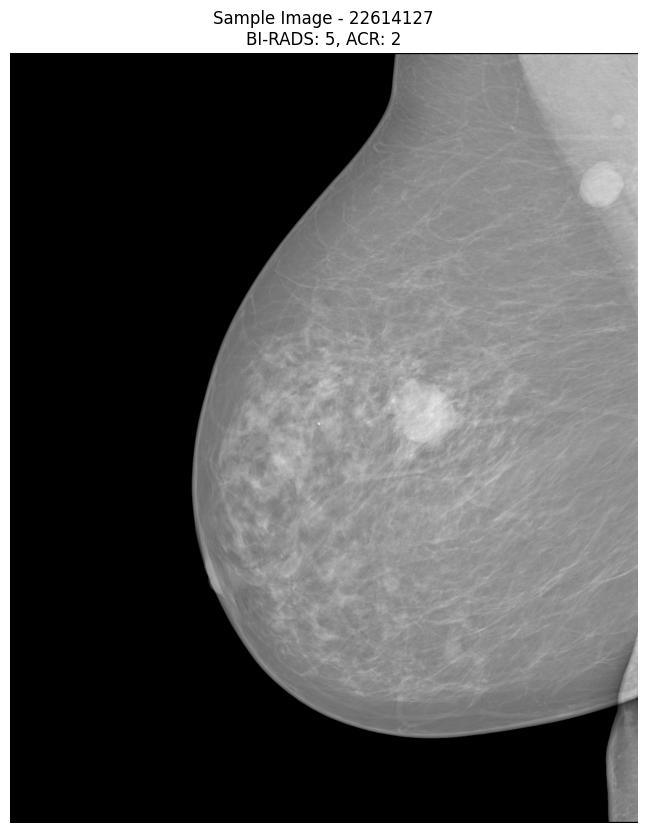

Image shape: (4084, 3328)
Pixel value range: [0, 2590]


In [28]:
# Load the DICOM file
if dicom_path.exists():
    dicom_data = pydicom.dcmread(dicom_path)
    img_array = dicom_data.pixel_array

    # Display the image
    plt.figure(figsize=(10, 10))
    plt.imshow(img_array, cmap='gray')
    plt.title(f"Sample Image - {sample_filename}\nBI-RADS: {sample_row['Bi-Rads']}, ACR: {sample_row['ACR']}")
    plt.axis('off')
    plt.show()

    print(f"Image shape: {img_array.shape}")
    print(f"Pixel value range: [{img_array.min()}, {img_array.max()}]")

In [29]:
file_name = sample_row["File Name"]
file_name

22614127

In [30]:
roi_file = INBREAST_ROOT / "AllROI" / (str(file_name) + ".roi")
print(f"ROI file: {roi_file}")
print(f"ROI file exists: {roi_file.exists()}")

ROI file: ../datasets/INbreast Release 1.0/AllROI/22614127.roi
ROI file exists: True


In [31]:
roi_file

PosixPath('../datasets/INbreast Release 1.0/AllROI/22614127.roi')

In [42]:
import re
from typedstream.stream import TypedStreamReader

def parse_point_string(s: bytes) -> tuple[float, float] | None:
    """Parse '{x, y}' format into tuple."""
    match = re.match(rb'\{([\d.]+),\s*([\d.]+)\}', s)
    if match:
        return float(match.group(1)), float(match.group(2))
    return None

def extract_rois(data):
    rois = []
    current_roi = None
    points = []
    label = None
    
    for item in data:
        item_str = str(item)
        
        # Detect ROI class start
        if 'class ROI' in item_str:
            if current_roi:
                rois.append(current_roi)
            current_roi = {'points': [], 'label': None, 'properties': []}
            points = []
            
        # Extract point coordinates
        if isinstance(item, bytes) and item.startswith(b'{') and b',' in item:
            point = parse_point_string(item)
            if point and current_roi:
                current_roi['points'].append(point)
                
        # Extract labels (Calcification, Mass, etc.)
        if isinstance(item, bytes) and item in (b'Calcification', b'Mass'):
            if current_roi:
                current_roi['label'] = item.decode()
    
    if current_roi:
        rois.append(current_roi)
    
    return rois

# Usage
reader = TypedStreamReader.from_data(roi_file.read_bytes())
items = list(reader)  # Flatten to list first
rois = extract_rois(items)

for i, roi in enumerate(rois):
    print(f"ROI {i}: {roi['label']} - {len(roi['points'])} points")

ROI 0: Mass - 134 points


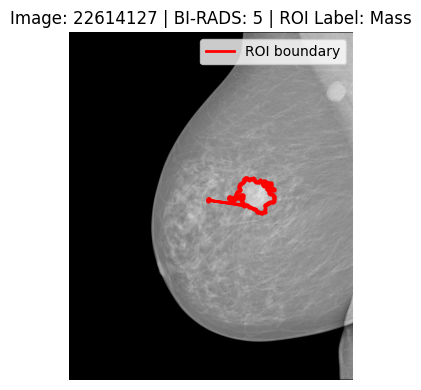

In [57]:
fig, ax = plt.subplots(figsize=(4, 4))

# Display the mammogram
ax.imshow(img_array, cmap='gray')

# Overlay the ROI
if roi['points']:
    roi_points = np.array([(a, b) for (a, b) in roi['points'] if a and b])
    # Close the polygon by connecting last point to first
    roi_points = np.vstack([roi_points, roi_points[0]])

    ax.plot(roi_points[:, 0], roi_points[:, 1], 'r-', linewidth=2, label='ROI boundary')
    ax.plot(roi_points[:, 0], roi_points[:, 1], 'r.', markersize=4)

ax.set_title(f"Image: {sample_filename} | BI-RADS: {sample_row['Bi-Rads']} | ROI Label: {roi['label']}")
ax.legend()
ax.axis('off')
plt.tight_layout()
plt.show()

### Parse and visualise region-of-interest

I create some help functions to explore the 

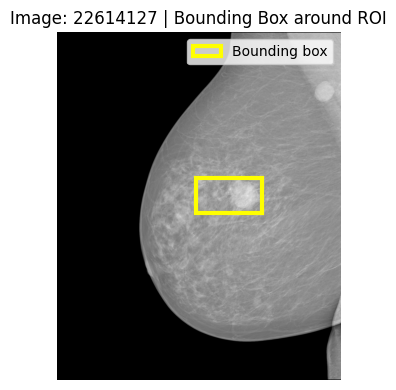

In [58]:
# Visualize with bounding box
if dicom_path.exists() and roi_file.exists():
    fig, ax = plt.subplots(figsize=(4, 4))

    # Display the mammogram
    ax.imshow(img_array, cmap='gray')

    # Overlay the bounding box
    if roi['points']:
        roi_points = np.array([(a, b) for (a, b) in roi['points'] if a and b])

        # Calculate bounding box
        x_min, y_min = roi_points.min(axis=0)
        x_max, y_max = roi_points.max(axis=0)

        # Draw the bounding box
        from matplotlib.patches import Rectangle
        bbox = Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                        linewidth=3, edgecolor='yellow', facecolor='none',
                        label='Bounding box')
        ax.add_patch(bbox)

    ax.set_title(f"Image: {sample_filename} | Bounding Box around ROI")
    ax.legend()
    ax.axis('off')
    plt.tight_layout()
    plt.show()

## EDA

Start by analysis key characteristics of the dataset.

### BI-RADS Assessment Distribution

The BI-RADS (Breast Imaging Reporting and Data System) assessment category indicates the level of suspicion:
- 1: Negative
- 2: Benign
- 3: Probably benign
- 4a, 4b, 4c: Suspicious
- 5: Highly suggestive of malignancy
- 6: Known biopsy-proven malignancy

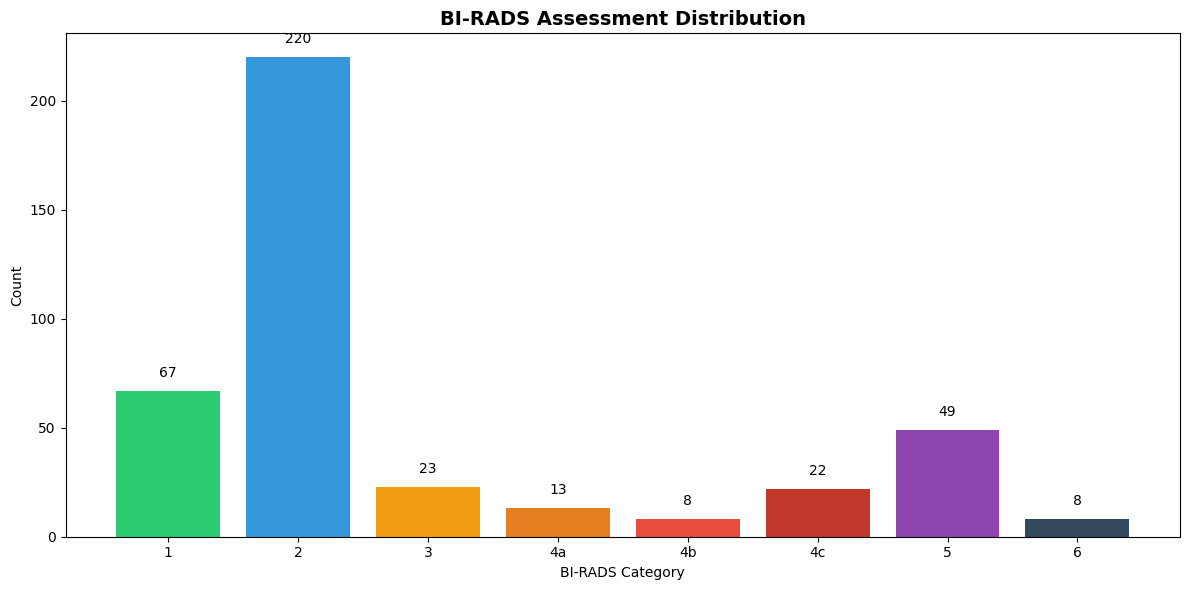

In [52]:
fig, ax = plt.subplots(figsize=(12, 6))

birads_counts = inbreast_df['Bi-Rads'].value_counts().sort_index()
colors = ['#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c', '#c0392b', '#8e44ad', '#34495e']
ax.bar(birads_counts.index.astype(str), birads_counts.values, color=colors[:len(birads_counts)])
ax.set_title('BI-RADS Assessment Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('BI-RADS Category')
ax.set_ylabel('Count')
for i, v in enumerate(birads_counts.values):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

Let's create binary labels for classification:
- Benign: BI-RADS 1, 2, 3
- Malignant: BI-RADS 4a, 4b, 4c, 5, 6

In [53]:
def classify_birads(birads):
    if birads in [1, 2, 3]:
        return 'Benign'
    elif birads in ['4a', '4b', '4c', 4, 5, 6]:
        return 'Malignant'
    else:
        return 'Unknown'

inbreast_df['pathology'] = inbreast_df['Bi-Rads'].apply(classify_birads)

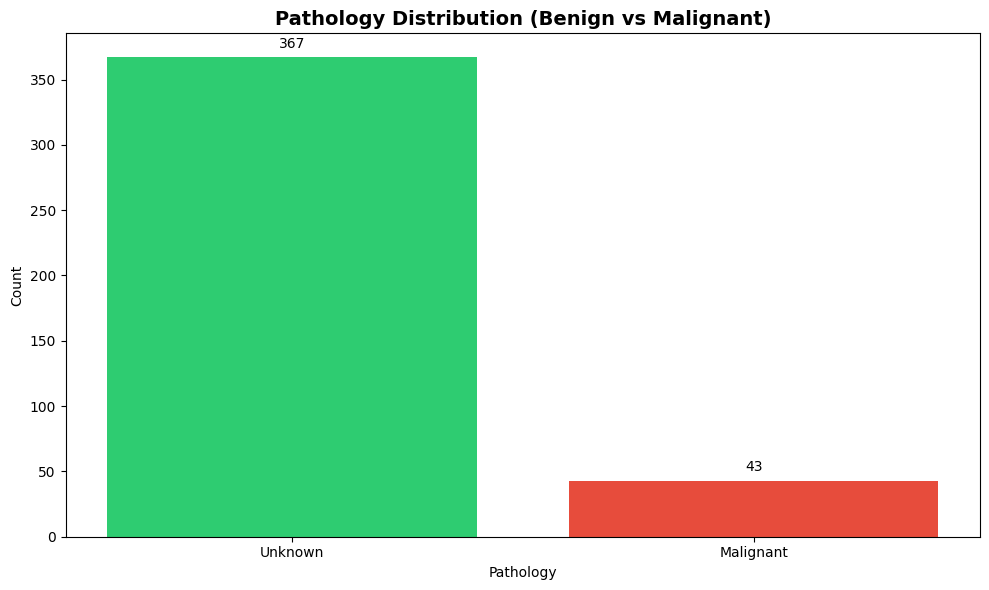

In [54]:
fig, ax = plt.subplots(figsize=(10, 6))

pathology_counts = inbreast_df['pathology'].value_counts()
colors_pathology = ['#2ecc71', '#e74c3c', '#95a5a6']
ax.bar(pathology_counts.index, pathology_counts.values, color=colors_pathology[:len(pathology_counts)])
ax.set_title('Pathology Distribution (Benign vs Malignant)', fontsize=14, fontweight='bold')
ax.set_xlabel('Pathology')
ax.set_ylabel('Count')
for i, v in enumerate(pathology_counts.values):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### ACR Breast Density Distribution

The ACR (American College of Radiology) breast density classification:
- 1: Almost entirely fatty
- 2: Scattered fibroglandular densities
- 3: Heterogeneously dense
- 4: Extremely dense

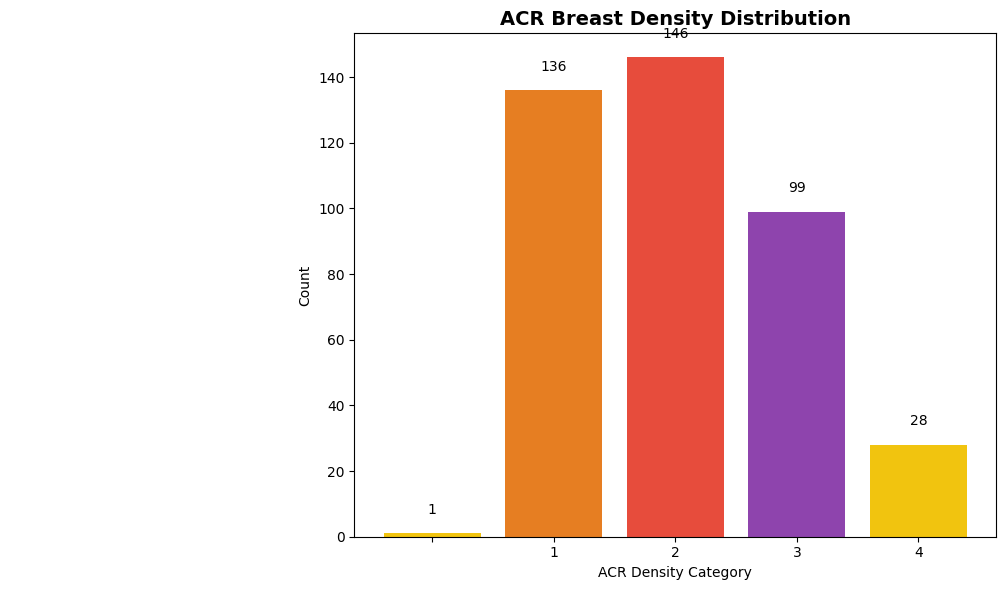

In [55]:
fig, ax = plt.subplots(figsize=(10, 6))

acr_counts = inbreast_df['ACR'].value_counts().sort_index()
# Filter out the empty string if it exists
acr_counts = acr_counts[acr_counts.index != '']
colors_acr = ['#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']
ax.bar(acr_counts.index.astype(str), acr_counts.values, color=colors_acr)
ax.set_title('ACR Breast Density Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('ACR Density Category')
ax.set_ylabel('Count')
for i, v in enumerate(acr_counts.values):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Image View Distribution

Standard mammography views:
- CC: Craniocaudal view
- MLO: Mediolateral oblique view

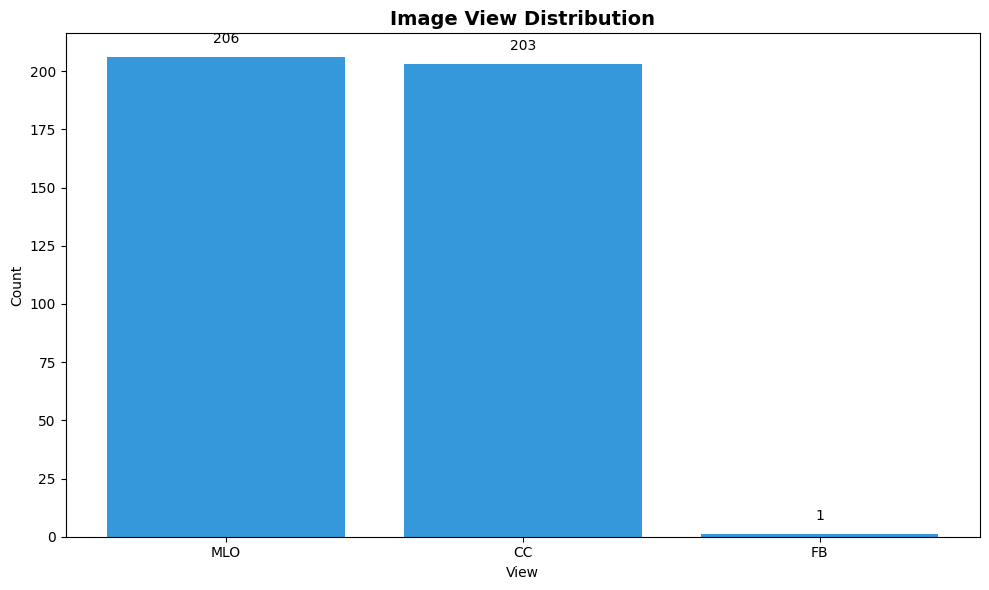

In [56]:
fig, ax = plt.subplots(figsize=(10, 6))

view_counts = inbreast_df['View'].value_counts()
ax.bar(view_counts.index, view_counts.values, color='#3498db')
ax.set_title('Image View Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('View')
ax.set_ylabel('Count')
for i, v in enumerate(view_counts.values):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Laterality Distribution

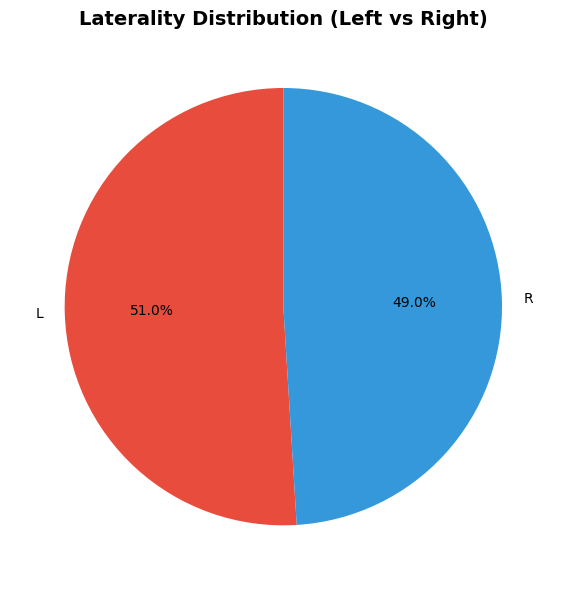

In [57]:
fig, ax = plt.subplots(figsize=(8, 6))

laterality_counts = inbreast_df['Laterality'].value_counts()
ax.pie(laterality_counts.values, labels=laterality_counts.index, autopct='%1.1f%%',
       colors=['#e74c3c', '#3498db'], startangle=90)
ax.set_title('Laterality Distribution (Left vs Right)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Cross-Analysis: BI-RADS by ACR Density

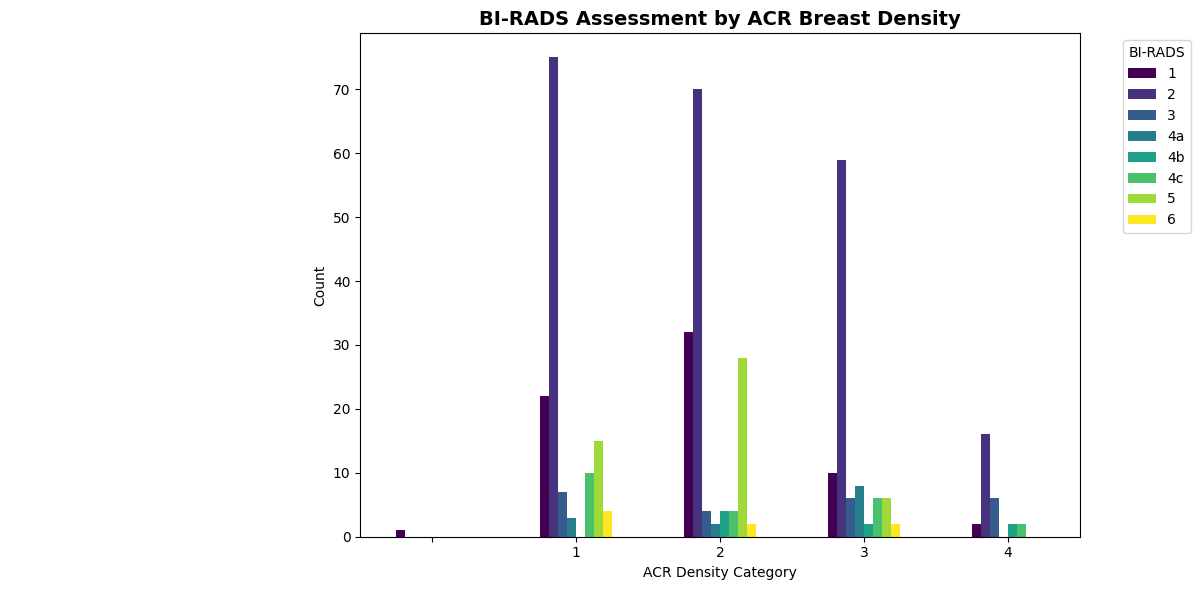

In [58]:
fig, ax = plt.subplots(figsize=(12, 6))

# Filter out empty ACR values
df_filtered = inbreast_df[inbreast_df['ACR'] != '']
birads_acr = pd.crosstab(df_filtered['ACR'], df_filtered['Bi-Rads'])
birads_acr.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_title('BI-RADS Assessment by ACR Breast Density', fontsize=14, fontweight='bold')
ax.set_xlabel('ACR Density Category')
ax.set_ylabel('Count')
ax.legend(title='BI-RADS', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Cross-Analysis: Pathology by View

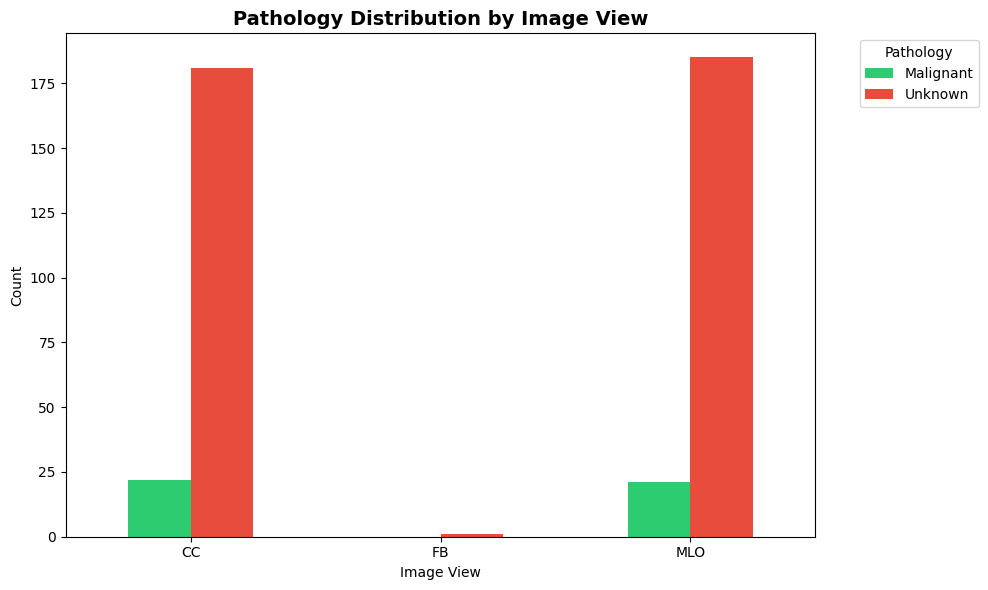

In [59]:
fig, ax = plt.subplots(figsize=(10, 6))

pathology_view = pd.crosstab(inbreast_df['View'], inbreast_df['pathology'])
pathology_view.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c', '#95a5a6'])
ax.set_title('Pathology Distribution by Image View', fontsize=14, fontweight='bold')
ax.set_xlabel('Image View')
ax.set_ylabel('Count')
ax.legend(title='Pathology', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Image Dimensions Analysis

Analyze the height and width distribution of images across the dataset.

In [60]:
from tqdm import tqdm

def get_image_dimensions(df, dicom_dir, desc="Processing"):
    """Extract image dimensions for all DICOM images in a dataframe."""
    dimensions = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        try:
            file_name = str(row['File Name'])
            dicom_files = list(dicom_dir.rglob(f"{file_name}*.dcm"))
            if dicom_files:
                dicom_data = pydicom.dcmread(dicom_files[0])
                height, width = dicom_data.pixel_array.shape
                dimensions.append({
                    "patient_id": row["Patient ID"],
                    "file_name": file_name,
                    "view": row["View"],
                    "width": width,
                    "height": height,
                    "aspect_ratio": width / height
                })
        except Exception as e:
            print(f"Error processing {row['File Name']}: {e}")
    return pd.DataFrame(dimensions)

In [61]:
dicom_dir = INBREAST_ROOT / "AllDICOMs"
dimensions_df = get_image_dimensions(inbreast_df, dicom_dir, desc="Analysing image dimensions")

Analysing image dimensions: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 410/410 [00:02<00:00, 187.23it/s]


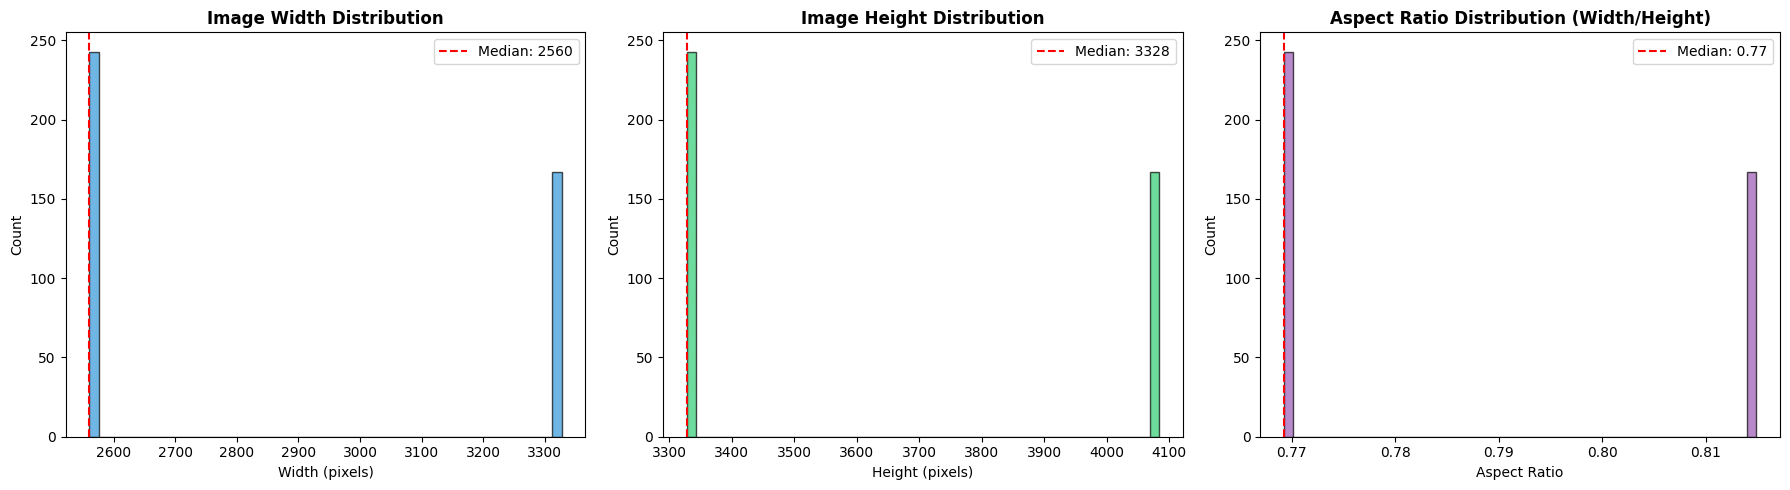

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Width distribution
axes[0].hist(dimensions_df['width'], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_title('Image Width Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Count')
axes[0].axvline(dimensions_df['width'].median(), color='red', linestyle='--',
                label=f"Median: {dimensions_df['width'].median():.0f}")
axes[0].legend()

# Height distribution
axes[1].hist(dimensions_df['height'], bins=50, color='#2ecc71', edgecolor='black', alpha=0.7)
axes[1].set_title('Image Height Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Height (pixels)')
axes[1].set_ylabel('Count')
axes[1].axvline(dimensions_df['height'].median(), color='red', linestyle='--',
                label=f"Median: {dimensions_df['height'].median():.0f}")
axes[1].legend()

# Aspect ratio distribution
axes[2].hist(dimensions_df['aspect_ratio'], bins=50, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[2].set_title('Aspect Ratio Distribution (Width/Height)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Aspect Ratio')
axes[2].set_ylabel('Count')
axes[2].axvline(dimensions_df['aspect_ratio'].median(), color='red', linestyle='--',
                label=f"Median: {dimensions_df['aspect_ratio'].median():.2f}")
axes[2].legend()

plt.tight_layout()
plt.show()

### Preprocessing Pipeline

Demonstrating the preprocessing pipeline on INbreast images, adapted from the CBIS-DDSM preprocessing.

In [63]:
import cv2
import matplotlib.patches as mpatches

#### Morphological Transformations

Morphological operations refine the binary mask by removing noise and filling gaps:

- **Opening** (erosion followed by dilation): Removes small bright spots/noise outside the breast region
- **Closing** (dilation followed by erosion): Fills small holes within the breast region

In [64]:
def apply_morphological_transforms(thresh_frame, iterations: int = 2):
    """Apply morphological opening and closing to clean up binary mask."""
    kernel = np.ones((100, 100), np.uint8)
    opened_mask = cv2.morphologyEx(thresh_frame, cv2.MORPH_OPEN, kernel)
    closed_mask = cv2.morphologyEx(opened_mask, cv2.MORPH_CLOSE, kernel, iterations=iterations)
    return closed_mask


def get_contours_from_mask(mask):
    """Find the largest contour and return its bounding box."""
    cnts, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnt = max(cnts, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(cnt)
    return (x, y, w, h)


def crop_coords(img_array):
    """Get bounding box coordinates for the breast ROI after thresholding pipeline."""
    if len(img_array.shape) > 2:
        img_array = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    # Normalize to 8-bit if needed
    if img_array.max() > 255:
        img_array = ((img_array - img_array.min()) / (img_array.max() - img_array.min()) * 255).astype(np.uint8)
    blur = cv2.GaussianBlur(img_array, (5, 5), 0)
    _, breast_mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    morph_img = apply_morphological_transforms(breast_mask)
    return get_contours_from_mask(morph_img)

#### Bounding Box Detection Example

Using Otsu's thresholding and morphological operations to detect the breast region.

In [65]:
# Load a sample MLO image for demonstration
sample_mlo = inbreast_df[inbreast_df.View == "MLO"].iloc[0]
sample_filename = sample_mlo['File Name']
dicom_path = list((INBREAST_ROOT / "AllDICOMs").rglob(f"{sample_filename}*.dcm"))[0]
dicom_data = pydicom.dcmread(dicom_path)
sample_img = dicom_data.pixel_array

In [66]:
# Normalize to 8-bit for processing
sample_img_8bit = ((sample_img - sample_img.min()) / (sample_img.max() - sample_img.min()) * 255).astype(np.uint8)

# Apply preprocessing steps
blurred_img = cv2.GaussianBlur(sample_img_8bit, (5, 5), 0)
_, breast_mask = cv2.threshold(blurred_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
morph_img = apply_morphological_transforms(breast_mask)

# Get bounding box
x, y, w, h = get_contours_from_mask(morph_img)

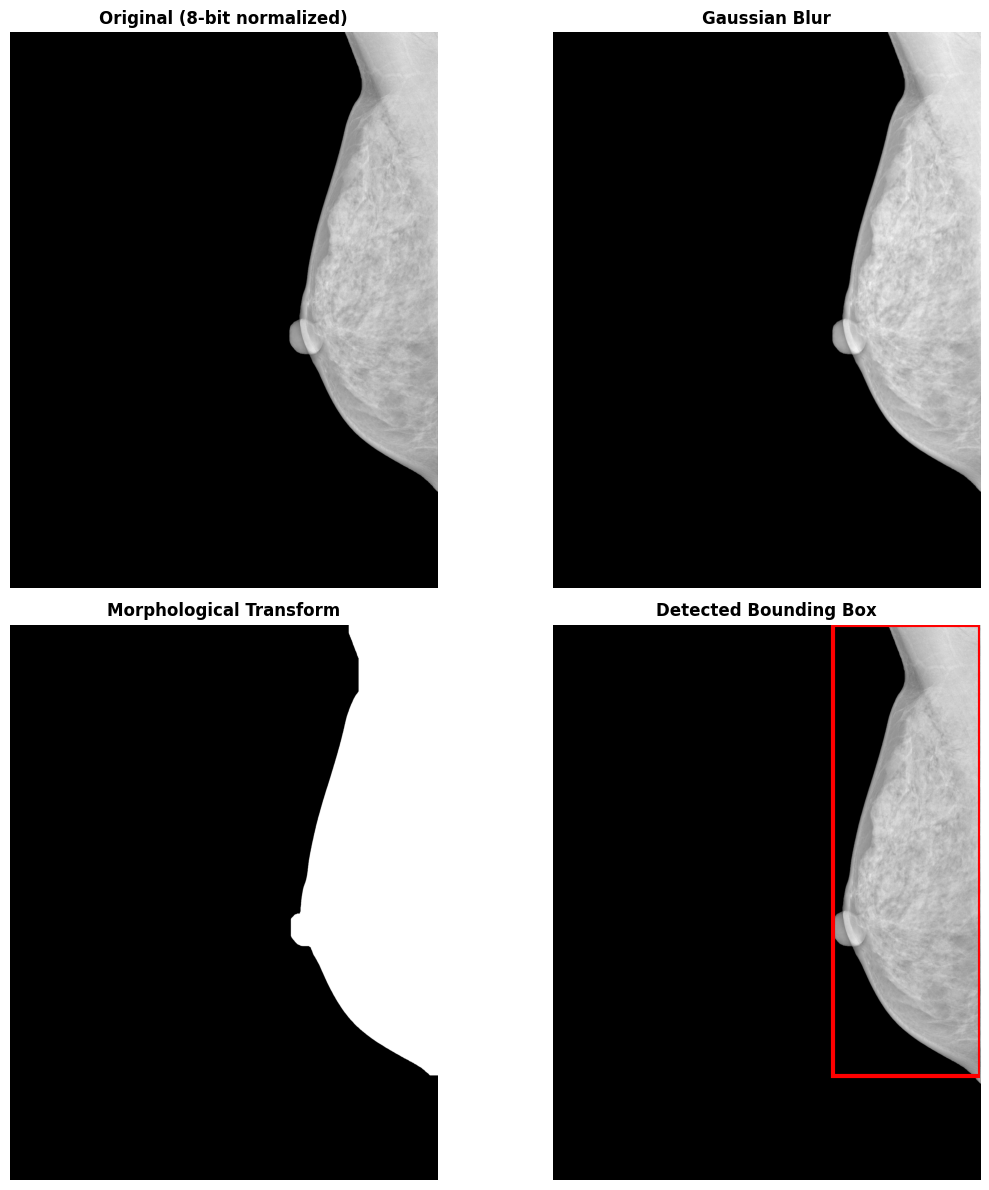

In [67]:
# Visualize the preprocessing steps
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].imshow(sample_img_8bit, cmap='gray')
axes[0, 0].set_title('Original (8-bit normalized)', fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(blurred_img, cmap='gray')
axes[0, 1].set_title('Gaussian Blur', fontweight='bold')
axes[0, 1].axis('off')

axes[1, 0].imshow(morph_img, cmap='gray')
axes[1, 0].set_title('Morphological Transform', fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(sample_img_8bit, cmap='gray')
rect = mpatches.Rectangle((x, y), w, h, linewidth=3, edgecolor='red', facecolor='none')
axes[1, 1].add_patch(rect)
axes[1, 1].set_title('Detected Bounding Box', fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

#### Truncation Normalisation

**Truncation normalisation** clips extreme pixel values using percentiles and scales to [0, 1]:
- Uses 5th and 99th percentiles to handle outliers
- More robust than min-max scaling for medical images

In [68]:
def truncation_normalisation(img):
    """
    Clip and normalize pixels in the breast ROI.
    Uses 5th and 99th percentiles to handle outliers.
    """
    Pmin = np.percentile(img[img != 0], 5)
    Pmax = np.percentile(img[img != 0], 99)
    truncated = np.clip(img, Pmin, Pmax)
    normalized = (truncated - Pmin) / (Pmax - Pmin)
    normalized[img == 0] = 0
    return normalized

#### CLAHE (Contrast Limited Adaptive Histogram Equalization)

CLAHE enhances local contrast while limiting noise amplification:
- Divides image into tiles and equalizes each independently
- Clip limit prevents over-amplification in homogeneous regions

In [69]:
def clahe(img, clip):
    """Apply CLAHE for image enhancement."""
    clahe_obj = cv2.createCLAHE(clipLimit=clip)
    cl = clahe_obj.apply(np.array(img * 255, dtype=np.uint8))
    return cl


def preprocess_mammogram(img_array, target_size=512):
    """
    Full preprocessing pipeline for a mammogram image.
    1. Crop to ROI bounding box
    2. Normalize using truncation normalization
    3. Enhance contrast with CLAHE at multiple clip levels
    4. Merge into 3-channel image
    5. Resize to target size
    """
    # Handle high bit-depth images
    if img_array.max() > 255:
        img_array = ((img_array - img_array.min()) / (img_array.max() - img_array.min()) * 255).astype(np.uint8)

    # Crop to ROI
    x, y, w, h = crop_coords(img_array)
    img_cropped = img_array[y:y+h, x:x+w]

    # Normalize
    img_normalized = truncation_normalisation(img_cropped)

    # Enhance contrast with different CLAHE clip limits
    cl1 = clahe(img_normalized, 1.0)
    cl2 = clahe(img_normalized, 2.0)

    # Merge into 3-channel image
    img_final = cv2.merge((np.array(img_normalized * 255, dtype=np.uint8), cl1, cl2))

    # Resize to target size
    img_final = cv2.resize(img_final, (target_size, target_size))

    return img_final

#### Full Pipeline Demonstration

The complete preprocessing pipeline outputs a 3-channel image:
- **Channel 1 (R)**: Original normalised image
- **Channel 2 (G)**: CLAHE with clip=1.0
- **Channel 3 (B)**: CLAHE with clip=2.0

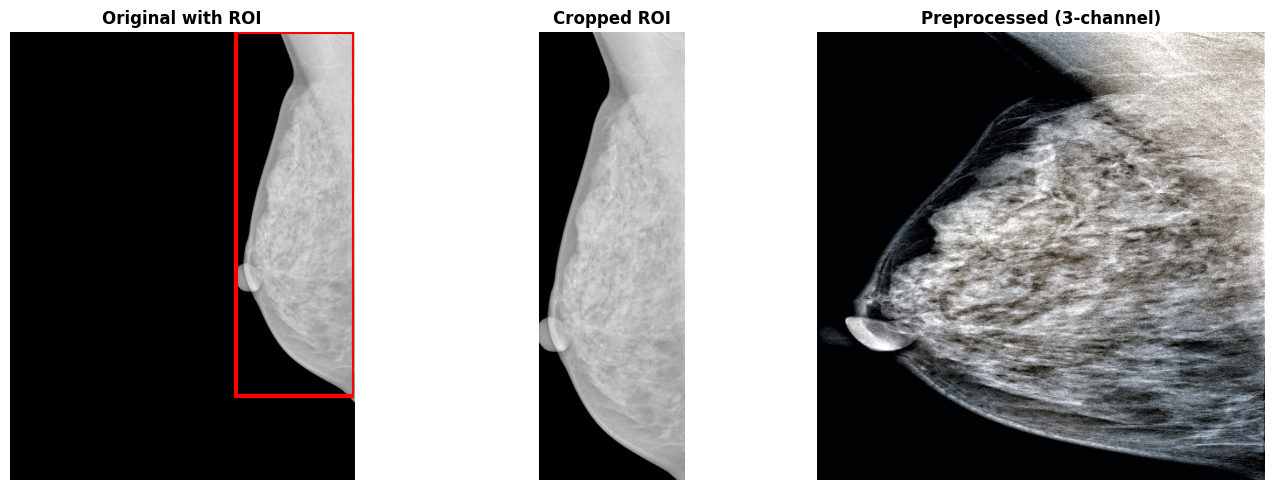

In [70]:
# Get ROI bounding box
x, y, w, h = crop_coords(sample_img)

# Display preprocessing pipeline
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].imshow(sample_img_8bit, cmap='gray')
rect = mpatches.Rectangle((x, y), w, h, linewidth=3, edgecolor='red', facecolor='none')
axes[0].add_patch(rect)
axes[0].set_title('Original with ROI', fontweight='bold')
axes[0].axis('off')

# Display cropped ROI
img_cropped = sample_img_8bit[y:y+h, x:x+w]
axes[1].imshow(img_cropped, cmap='gray')
axes[1].set_title('Cropped ROI', fontweight='bold')
axes[1].axis('off')

# Display final preprocessed image
img_final = preprocess_mammogram(sample_img)
axes[2].imshow(img_final)
axes[2].set_title('Preprocessed (3-channel)', fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

#### Pixel Distribution Before and After Normalisation

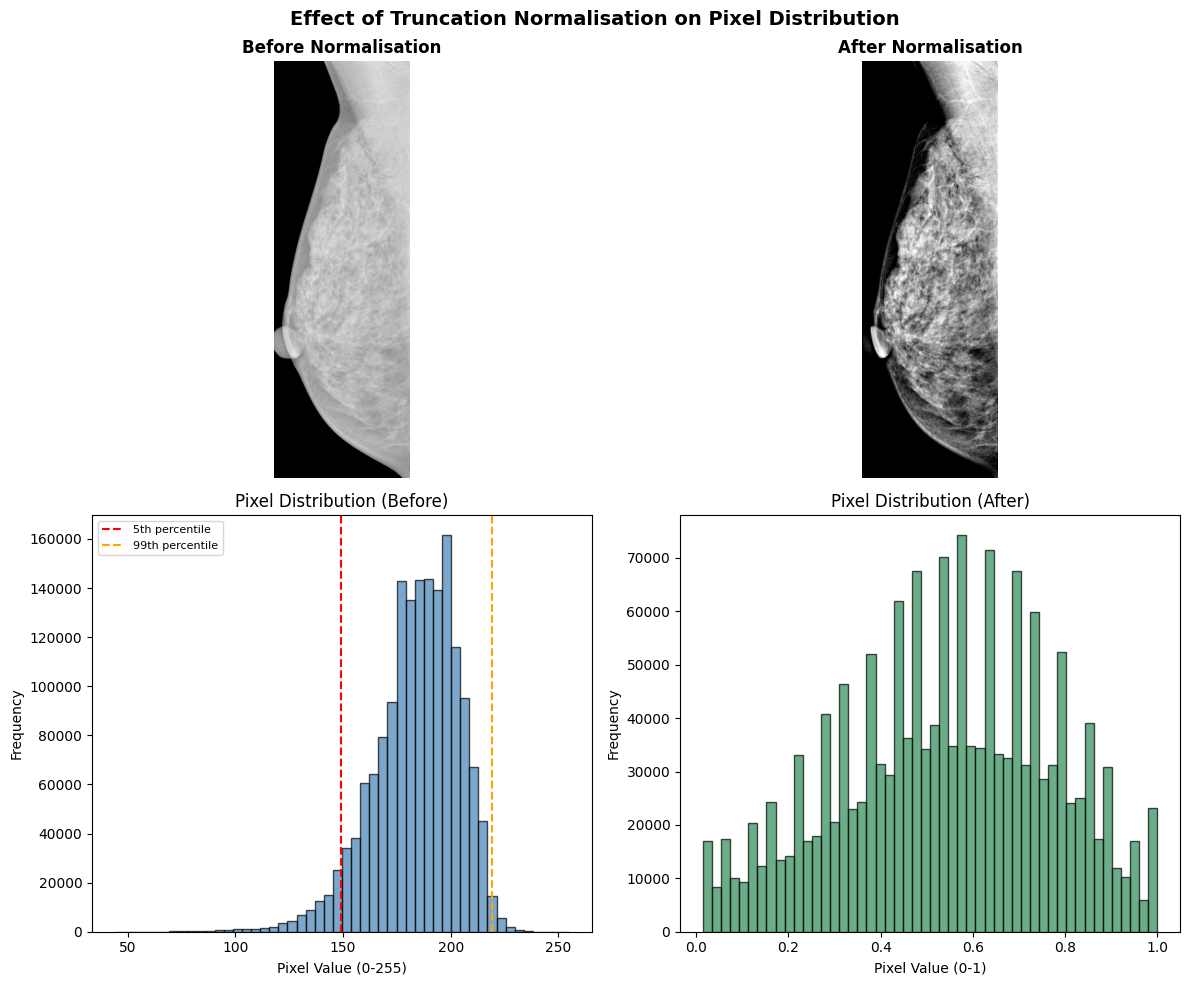

Before: min=44, max=255, mean=184.2, std=19.6
After:  min=0.014, max=1.000, mean=0.539, std=0.230


In [71]:
# Prepare cropped image for comparison
img_cropped = sample_img_8bit[y:y+h, x:x+w]
trunc_img = truncation_normalisation(img_cropped)

# Create figure with images and histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Before normalisation - image
axes[0, 0].imshow(img_cropped, cmap='gray')
axes[0, 0].set_title('Before Normalisation', fontweight='bold')
axes[0, 0].axis('off')

# Before normalisation - histogram
pixels_before = img_cropped[img_cropped > 0].flatten()
axes[1, 0].hist(pixels_before, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Pixel Value (0-255)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Pixel Distribution (Before)')
axes[1, 0].axvline(x=np.percentile(pixels_before, 5), color='red', linestyle='--', label='5th percentile')
axes[1, 0].axvline(x=np.percentile(pixels_before, 99), color='orange', linestyle='--', label='99th percentile')
axes[1, 0].legend(fontsize=8)

# After normalisation - image
axes[0, 1].imshow(trunc_img, cmap='gray')
axes[0, 1].set_title('After Normalisation', fontweight='bold')
axes[0, 1].axis('off')

# After normalisation - histogram
pixels_after = trunc_img[trunc_img > 0].flatten()
axes[1, 1].hist(pixels_after, bins=50, color='seagreen', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Pixel Value (0-1)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Pixel Distribution (After)')

plt.suptitle('Effect of Truncation Normalisation on Pixel Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print statistics
print(f"Before: min={pixels_before.min()}, max={pixels_before.max()}, mean={pixels_before.mean():.1f}, std={pixels_before.std():.1f}")
print(f"After:  min={pixels_after.min():.3f}, max={pixels_after.max():.3f}, mean={pixels_after.mean():.3f}, std={pixels_after.std():.3f}")